# NB 07 — Analysis, Interpretation & Final Reporting


**Phase 5 — Tasks 5.1 / 5.2 / 5.3**

Produces:
- Complete model comparison table (batch + stream)
- Stylometric feature importance chart
- Error analysis — false positives / false negatives
- Per-AI-model detection difficulty
- Generation method accuracy breakdown
- Publication-quality figures

In [1]:
# ── Session bootstrap ─────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys, shutil, importlib
from pathlib import Path

PROJECT_ROOT = Path('/content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection')
SRC_DIR = PROJECT_ROOT / 'src'

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f'Project root not found: {PROJECT_ROOT}')

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# src/__init__.py is committed to the repo, no runtime touch needed
print('PROJECT_ROOT:', PROJECT_ROOT)


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection


In [2]:
# Install Arabic rendering support
!pip -q install arabic-reshaper python-bidi
!apt-get -qq update
!apt-get -qq install -y fonts-noto-core fonts-noto-extra fonts-hosny-amiri

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 5.9 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-hosny-amiri.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../fonts-hosny-amiri_0.113-1_all.deb ...
Unpacking fonts-hosny-amiri (0.113-1) ...
Selecting previously unselected package fonts-noto-core.
Preparing to unpack .../fonts-noto-core_20201225-1build1_all.deb ...
Unpacking fonts-noto-core (20201225-1build1) ...
Selecting previously unselected package fonts-noto-extra.
Preparing to unpack .../fonts-noto-extra_20201225-1build1_all.deb ...
Unpacking fonts-noto-extra (20201225-1build1) ...
Setting up fonts-noto-extra (20201225-1build1) ...
Setting up fonts-hosny-amiri (0.113-1) ...
Setting up fonts-noto-core (20201225-1build1) ..

In [3]:
from src.utils import (
    create_spark_session, load_checkpoint, add_src_to_spark,
    FIGURES_DIR, MODELS_DIR, PROJECT_ROOT, FEAT_PREFIX
)
from src.modeling import load_model, evaluate_model, confusion_matrix_spark, extract_feature_importances
from src.feature_engineering import FEATURE_COLS, _FEATURE_REGISTRY
from pyspark.sql import functions as F
from pyspark.ml import PipelineModel
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

plt.rcParams.update({
    'font.family': 'Amiri',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
})
PALETTE = {'Human': '#4A90D9', 'AI': '#E8603C'}

spark = create_spark_session('ArabicAIDetection_Analysis')
add_src_to_spark(spark)
print('Session ready.')


Session ready.


## 1. Load all artifacts

In [4]:
test_df = load_checkpoint(spark, 'split_test_assembled')
models  = {
    'Logistic Regression': load_model(spark, 'logistic_regression'),
    'Random Forest':       load_model(spark, 'random_forest'),
    'Linear SVM':          load_model(spark, 'linear_svm'),
}
print('Models loaded:', list(models.keys()))
print(f'Test rows: {test_df.count():,}')


Models loaded: ['Logistic Regression', 'Random Forest', 'Linear SVM']
Test rows: 6,180


## 2. Load / recompute test metrics

In [5]:
try:
    test_results = pd.read_csv(str(FIGURES_DIR / 'test_metrics.csv'), index_col=0)
    print('Pre-computed test metrics loaded.')
except FileNotFoundError:
    print('Recomputing test metrics …')
    rows = [evaluate_model(m, test_df, name) for name, m in models.items()]
    test_results = pd.DataFrame(rows).set_index('model')
    test_results.to_csv(str(FIGURES_DIR / 'test_metrics.csv'))

print(test_results[['accuracy','f1','precision','recall','roc_auc']].to_string())


Pre-computed test metrics loaded.
                    accuracy      f1  precision  recall  roc_auc
model                                                           
LogisticRegression    0.9817  0.9818     0.9820  0.9817   0.9948
RandomForest          0.8011  0.7137     0.8407  0.8011   0.9838
LinearSVM             0.9786  0.9788     0.9793  0.9786   0.9947


## 3. Task 5.1 — Batch vs stream comparison

In [6]:
try:
    bench_df       = pd.read_csv(str(FIGURES_DIR / 'scalability_benchmark.csv'))
    max_batch_rps  = bench_df['rows_per_sec'].max()
    min_batch_time = bench_df['elapsed_s'].min()
except FileNotFoundError:
    max_batch_rps, min_batch_time = None, None

try:
    stream_prog    = pd.read_csv(str(FIGURES_DIR / 'stream_progress_log.csv'))
    avg_stream_rps = stream_prog['proc_rps'].mean()
    avg_stream_lat = 5.0
except FileNotFoundError:
    avg_stream_rps, avg_stream_lat = None, None

comparison = pd.DataFrame([
    {'Pipeline': 'Batch (Spark MLlib)',
     'Latency':    f'{min_batch_time:.1f}s (full set)' if min_batch_time else 'N/A',
     'Throughput': f'{max_batch_rps:.0f} rows/s'       if max_batch_rps  else 'N/A',
     'Use case':   'Offline bulk classification',
     'Fault tol.': 'Parquet checkpoint'},
    {'Pipeline': 'Stream (Structured Streaming)',
     'Latency':    f'~{avg_stream_lat:.0f}s (micro-batch)' if avg_stream_lat else 'N/A',
     'Throughput': f'{avg_stream_rps:.0f} rows/s'          if avg_stream_rps else 'N/A',
     'Use case':   'Real-time detection',
     'Fault tol.': 'Streaming checkpoint + WAL'},
])
print('\n── Batch vs Stream ──')
print(comparison.to_string(index=False))
comparison.to_csv(str(FIGURES_DIR / 'batch_vs_stream.csv'), index=False)



── Batch vs Stream ──
                     Pipeline           Latency   Throughput                    Use case                 Fault tol.
          Batch (Spark MLlib)   0.3s (full set) 18098 rows/s Offline bulk classification         Parquet checkpoint
Stream (Structured Streaming) ~5s (micro-batch)     6 rows/s         Real-time detection Streaming checkpoint + WAL


## 4. Publication-quality model performance chart

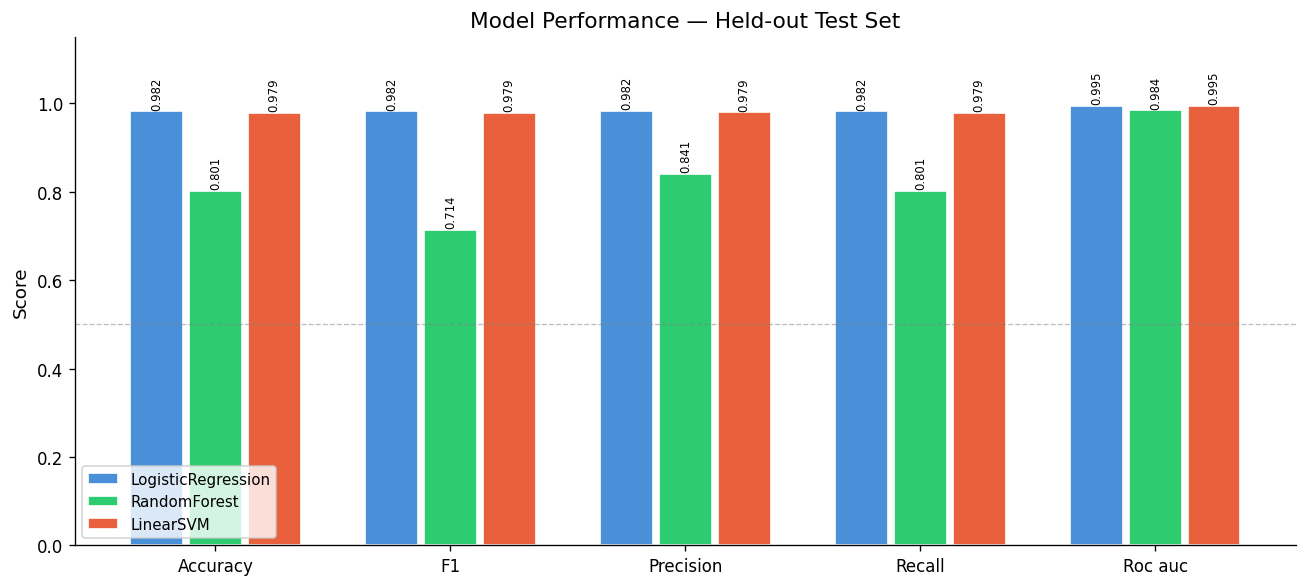

In [7]:
metrics = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
x, width, colors = np.arange(len(metrics)), 1.0/(len(models)+1), ['#4A90D9','#2ECC71','#E8603C']

fig, ax = plt.subplots(figsize=(11, 5))
for i, (name, row) in enumerate(test_results.iterrows()):
    offset = (i - len(models)/2 + 0.5) * width
    bars = ax.bar(x + offset, [row[m] for m in metrics],
                  width * 0.9, label=name, color=colors[i], edgecolor='white')
    for bar, v in zip(bars, [row[m] for m in metrics]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([m.replace('_',' ').capitalize() for m in metrics], fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Performance — Held-out Test Set', fontsize=13)
ax.legend(fontsize=9)
ax.axhline(0.5, color='grey', linestyle='--', lw=0.8, alpha=0.5)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'final_model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


## 5. Task 5.2 — Stylometric feature importance analysis

In [8]:
rf_model = models['Random Forest']
rf_stage = rf_model.stages[-1]
n_tfidf  = 20_000
all_names = FEATURE_COLS + [f'tfidf_{i}' for i in range(n_tfidf)]

all_imp  = extract_feature_importances(rf_stage, all_names, top_n=len(all_names))
imp_df   = pd.DataFrame(all_imp, columns=['feature', 'importance'])
stylo_imp = imp_df[imp_df['feature'].str.startswith(FEAT_PREFIX)].copy()
tfidf_imp = imp_df[imp_df['feature'].str.startswith('tfidf')].copy()

print(f'Total stylometric importance: {stylo_imp["importance"].sum():.4f}')
print(f'Total TF-IDF importance:      {tfidf_imp["importance"].sum():.4f}')

stylo_imp = stylo_imp.sort_values('importance', ascending=False)
stylo_imp['short'] = stylo_imp['feature'].str.replace(FEAT_PREFIX, '', regex=False)
print('\n── Stylometric features ranked ──')
print(stylo_imp[['short','importance']].to_string(index=False))


Total stylometric importance: 0.0832
Total TF-IDF importance:      0.9168

── Stylometric features ranked ──
                short  importance
     f22_word_entropy    0.018537
     f67_num_singular    0.014177
       f1_total_chars    0.012185
  f4_whitespace_ratio    0.011177
      f13_hapax_ratio    0.010017
        f43_num_nouns    0.005415
      f46_num_adverbs    0.004172
  f64_num_nominatives    0.003446
  f55_noun_verb_ratio    0.001833
    f34_num_sentences    0.000842
f85_sent_len_variance    0.000784
         f97_bert_sim    0.000566
     f88_semantic_sim    0.000083
    f106_tanween_freq    0.000000
    f25_single_quotes    0.000000
       f109_link_freq    0.000000
    f76_passive_sents    0.000000


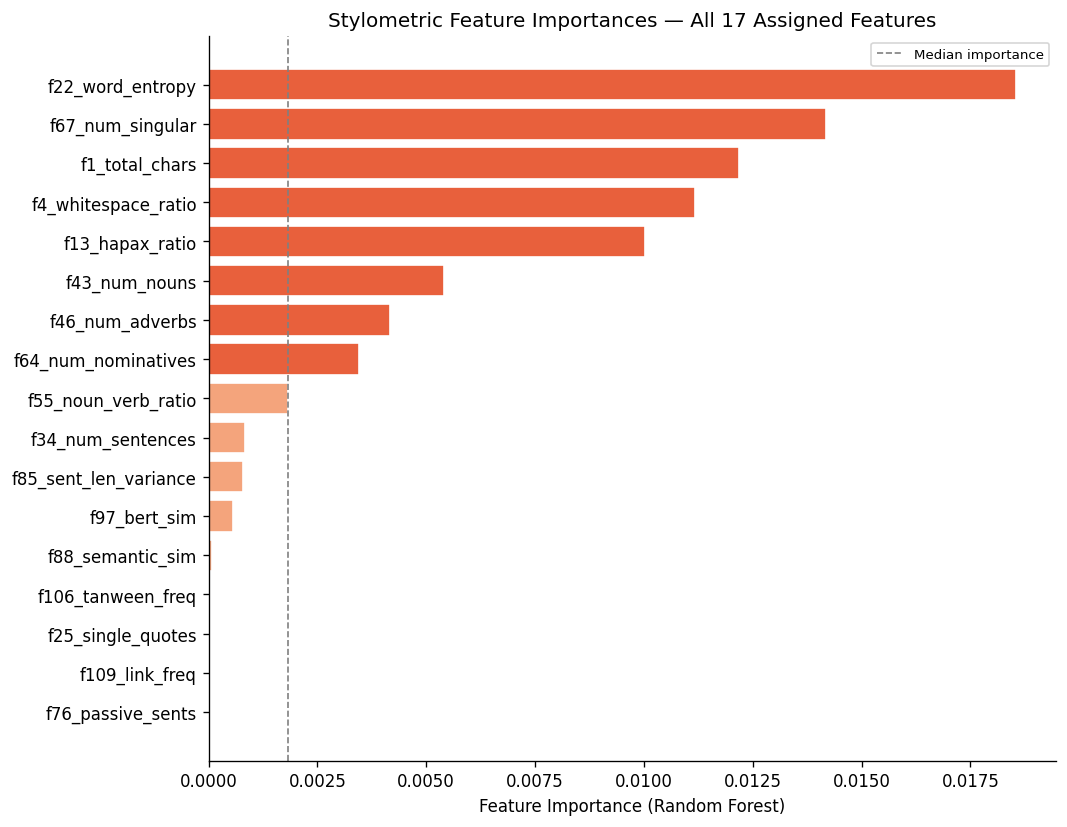

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
bar_colors = ['#E8603C' if imp > stylo_imp['importance'].median() else '#F4A47C'
              for imp in stylo_imp['importance']]
ax.barh(stylo_imp['short'][::-1], stylo_imp['importance'][::-1],
        color=bar_colors[::-1], edgecolor='white')
ax.set_xlabel('Feature Importance (Random Forest)', fontsize=10)
ax.set_title('Stylometric Feature Importances — All 17 Assigned Features', fontsize=12)
ax.axvline(stylo_imp['importance'].median(), color='grey', linestyle='--',
           lw=1.0, label='Median importance')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'stylometric_importances.png'), dpi=150)
plt.show()


## 6. Error analysis — false positives & false negatives

In [11]:
best_name  = test_results['f1'].idxmax()
best_model = models['Logistic Regression']
print(f'Error analysis on best model: {best_name}')

preds_df = best_model.transform(test_df)

fp_df = preds_df.filter((F.col('label') == 0) & (F.col('prediction') == 1))
fn_df = preds_df.filter((F.col('label') == 1) & (F.col('prediction') == 0))

print(f'False Positives (human predicted as AI): {fp_df.count():,}')
print(f'False Negatives (AI predicted as human): {fn_df.count():,}')


Error analysis on best model: LogisticRegression
False Positives (human predicted as AI): 41
False Negatives (AI predicted as human): 72


In [12]:
fn_by_model = (
    fn_df.groupBy('source_model').count()
         .withColumnRenamed('count', 'false_negatives')
         .orderBy('false_negatives', ascending=False)
)
print('── False negatives by AI model (hardest to detect) ──')
fn_by_model.show()


── False negatives by AI model (hardest to detect) ──
+------------+---------------+
|source_model|false_negatives|
+------------+---------------+
|       llama|             46|
|        jais|             16|
|       allam|              6|
|      openai|              4|
+------------+---------------+



## 7. Per-AI-model detection accuracy

── Detection accuracy by AI source model ──
 model  accuracy    n
 allam  0.994928 1183
  jais  0.987352 1265
 llama  0.962753 1235
openai  0.996830 1262


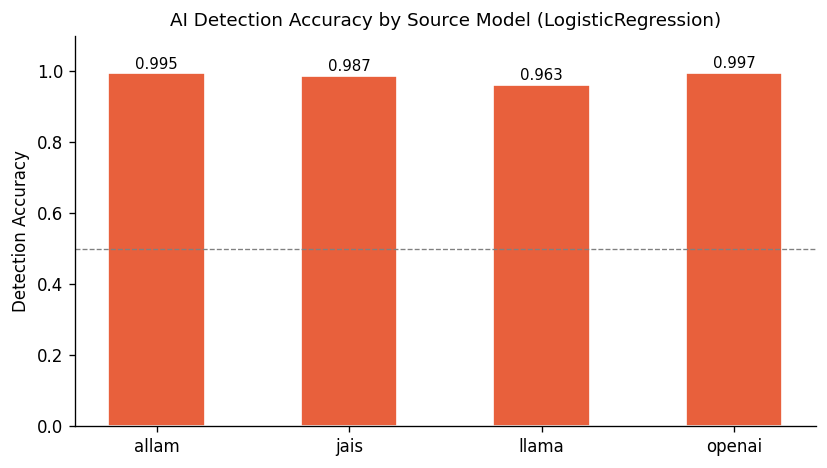

In [13]:
per_model = []
for src in ['allam', 'jais', 'llama', 'openai']:
    sub = preds_df.filter(F.col('source_model') == src)
    n   = sub.count()
    if n == 0: continue
    correct = sub.filter(F.col('label') == F.col('prediction')).count()
    per_model.append({'model': src, 'accuracy': correct/n, 'n': n})

pm_df = pd.DataFrame(per_model)
print('── Detection accuracy by AI source model ──')
print(pm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(pm_df['model'], pm_df['accuracy'], color='#E8603C', edgecolor='white', width=0.5)
for bar, v in zip(bars, pm_df['accuracy']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='grey', linestyle='--', lw=0.8)
ax.set_ylabel('Detection Accuracy')
ax.set_title(f'AI Detection Accuracy by Source Model ({best_name})', fontsize=11)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'detection_by_model.png'), dpi=150)
plt.show()


## 8. Generation method accuracy breakdown

+--------------------+------------------+---------+
|   generation_method|          accuracy|n_records|
+--------------------+------------------+---------+
|        by_polishing|0.9738717339667459|     2105|
|          from_title| 0.991414369633981|     2213|
|from_title_and_co...|0.9790547798066596|     1862|
+--------------------+------------------+---------+



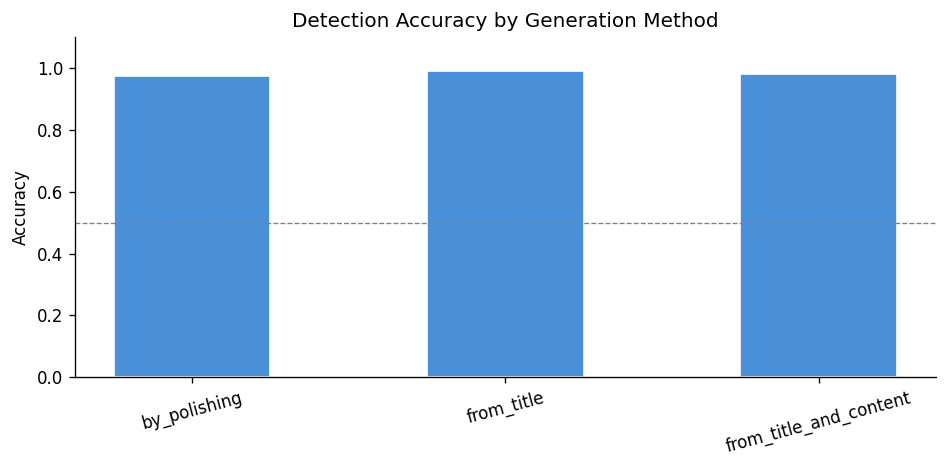

In [14]:
gen_acc = (
    preds_df
    .withColumn('correct', (F.col('label') == F.col('prediction')).cast('int'))
    .groupBy('generation_method')
    .agg(F.avg('correct').alias('accuracy'), F.count('*').alias('n_records'))
    .orderBy('generation_method')
)
gen_acc.show()

gen_pdf = gen_acc.toPandas()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(gen_pdf['generation_method'], gen_pdf['accuracy'],
       color='#4A90D9', edgecolor='white', width=0.5)
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color='grey', linestyle='--', lw=0.8)
ax.set_ylabel('Accuracy')
ax.set_title('Detection Accuracy by Generation Method')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
fig.savefig(str(FIGURES_DIR / 'accuracy_by_generation_method.png'), dpi=150)
plt.show()


## 9. Summary statistics for report

In [15]:
best_row = test_results.loc[best_name]
print('=' * 55)
print('  FINAL PROJECT SUMMARY')
print('=' * 55)
print(f'  Dataset            : KFUPM-JRCAI/arabic-generated-abstracts')
print(f'  Total samples      : 8,388  (3 generation methods)')
print(f'  Stylometric feats  : 17 (students i=1, i=4, i=13, n=21)')
print(f'  TF-IDF vocab       : 20,000 hash buckets')
print(f'  Best model         : {best_name}')
print(f'  Test Accuracy      : {best_row["accuracy"]:.4f}')
print(f'  Test F1            : {best_row["f1"]:.4f}')
print(f'  Test ROC-AUC       : {best_row["roc_auc"]:.4f}')
print('=' * 55)
print('Figures saved to:', FIGURES_DIR)
saved = list(FIGURES_DIR.glob('*.png')) + list(FIGURES_DIR.glob('*.csv'))
for f in sorted(saved):
    print(' ', f.name)


  FINAL PROJECT SUMMARY
  Dataset            : KFUPM-JRCAI/arabic-generated-abstracts
  Total samples      : 8,388  (3 generation methods)
  Stylometric feats  : 17 (students i=1, i=4, i=13, n=21)
  TF-IDF vocab       : 20,000 hash buckets
  Best model         : LogisticRegression
  Test Accuracy      : 0.9817
  Test F1            : 0.9818
  Test ROC-AUC       : 0.9948
Figures saved to: /content/drive/MyDrive/MSBDA-801-Project/arabic_ai_detection/reports/figures
  accuracy_by_generation_method.png
  avg_word_count_by_model_split.png
  avg_word_count_table.csv
  batch_vs_stream.csv
  confusion_matrices.png
  detection_by_model.png
  feature_importances.png
  final_model_comparison.png
  model_comparison_val.png
  ngrams_ai.png
  ngrams_human.png
  ngrams_unigrams_by_polishing.png
  ngrams_unigrams_from_title.png
  ngrams_unigrams_from_title_and_content.png
  scalability_benchmark.csv
  scalability_benchmark.png
  stream_progress_log.csv
  stream_throughput.png
  stylometric_importances.